# Univariate Linear Regression: the Normal Equations

> 📖 Book: [ch03 – Least squares](../../.claude/skills/ml-knowledge/chapters/ch03-least-squares-pseudoinverse-tikhonov.md), [ch04 – Linear regression](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Next: [02 Gradient descent](02_gradient_descent_theory.ipynb)

Linear regression builds a continuous, linear relationship between input data and the known outputs. Computing it is a classic least-squares problem: with inputs in a matrix $X$ and outputs in a vector $y$, we look for $\theta$ such that

$$
X\theta = y, \qquad
X = \begin{pmatrix} 1 & x^{(1)} \\ 1 & x^{(2)} \\ \vdots & \vdots \\ 1 & x^{(m)} \end{pmatrix}, \quad
\theta = \begin{pmatrix} \theta_0 \\ \theta_1 \end{pmatrix}, \quad
y = \begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{pmatrix}.
$$

The solution could be as simple as $\theta = X^{-1}y$, but $X$ is rectangular ($m \times 2$) and in practice has no inverse.

## Example: house prices

We want to sell a $1000\,m^2$ house and estimate its price. From an online database of past sales we build this table:

| Size ($m^2$) | Price (USD) |
|:---:|:---:|
| 820 | 70000 |
| 910 | 83000 |
| 1100 | 75000 |
| 1100 | 93000 |
| 1400 | 90000 |
| 1400 | 80000 |
| 1500 | 85000 |
| 1600 | 114000 |
| 1804 | 150000 |
| 2010 | 160050 |
| 2040 | 170000 |
| 2500 | 175000 |
| 3200 | 180000 |
| 3400 | 190000 |

The price column "supervises" the learning. We propose $y = \theta_0 + \theta_1 x$ and write one equation per house, $y^{(i)} = (1, x^{(i)})(\theta_0, \theta_1)^T$:

$$
\begin{pmatrix} 1 & 820 \\ 1 & 910 \\ \vdots & \vdots \\ 1 & 3400 \end{pmatrix}
\begin{pmatrix} \theta_0 \\ \theta_1 \end{pmatrix} =
\begin{pmatrix} 70000 \\ 83000 \\ \vdots \\ 190000 \end{pmatrix}.
$$

The column of ones accounts for the intercept $\theta_0$, also called the **bias** term. This system has no solution: $y$ is not in the range of $X$, i.e. no single line passes through all the points. Let's look at the data first.

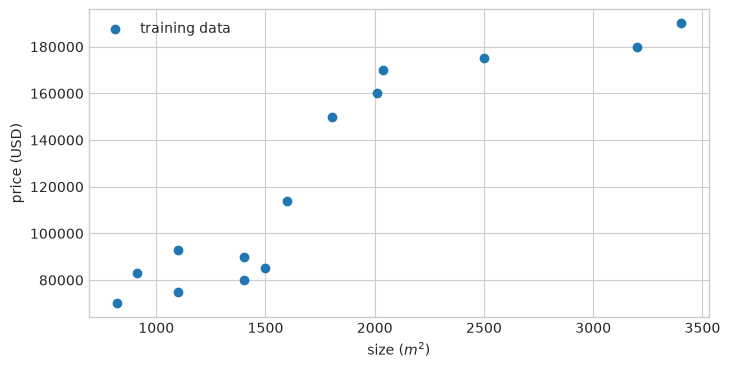

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.linear_models import add_bias, mse_cost, normal_equations

plt.style.use("seaborn-v0_8-whitegrid")

x = np.array([820, 910, 1100, 1100, 1400, 1400, 1500, 1600, 1804, 2010, 2040, 2500, 3200, 3400], dtype=float)
y = np.array([70000, 83000, 75000, 93000, 90000, 80000, 85000, 114000, 150000, 160050, 170000, 175000, 180000, 190000], dtype=float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, label="training data")
ax.set(xlabel="size ($m^2$)", ylabel="price (USD)")
ax.legend()
plt.show()

The best we can do is minimize the total squared error between each price $y^{(i)}$ and the model $h_\theta(\mathbf{x}^{(i)}) = \mathbf{x}^{(i)T}\theta$:

$$
\sum_{i=1}^m \left(h_\theta(\mathbf{x}^{(i)}) - y^{(i)}\right)^2 = \sum_{i=1}^m \left(\mathbf{x}^{(i)T}\theta - y^{(i)}\right)^2 = \|X\theta - y\|^2 .
$$

## The normal equations

Setting the gradient of $\frac12\|X\theta - y\|^2$ to zero, $X^T(X\theta - y) = 0$, gives the **normal equations**

$$
X^TX\theta = X^Ty \quad\Longrightarrow\quad \theta = (X^TX)^{-1}X^Ty .
$$

Geometrically: $X\theta$ is the **orthogonal projection** of $y$ onto the column space of $X$, and the residual $X\theta - y$ is perpendicular to every column of $X$.

Numerically we never form the inverse: `ml.linear_models.normal_equations` uses `np.linalg.lstsq` (SVD based), which also returns the minimum-norm solution $\theta = X^+y$ when $X^TX$ is singular.

In [2]:
X = add_bias(x)
theta_inv = np.linalg.inv(X.T @ X) @ X.T @ y  # textbook formula, for comparison only
theta = normal_equations(X, y)
print("theta (explicit inverse):", theta_inv)
print("theta (lstsq)           :", theta)
print("residual orthogonal to columns of X:", np.allclose(X.T @ (X @ theta - y), 0, atol=1e-3))

theta (explicit inverse): [30994.74367923    51.69155861]
theta (lstsq)           : [30994.74367923    51.69155861]
residual orthogonal to columns of X: True


Once $\theta$ is learned we can predict $y$ for any house size with the **hypothesis**

$$
h_\theta(\mathbf{x}) = \mathbf{x}^T\theta = \begin{pmatrix} 1 & x \end{pmatrix}\begin{pmatrix} \theta_0 \\ \theta_1 \end{pmatrix}.
$$

Estimated price of a 1000 m^2 house: 82,686 USD


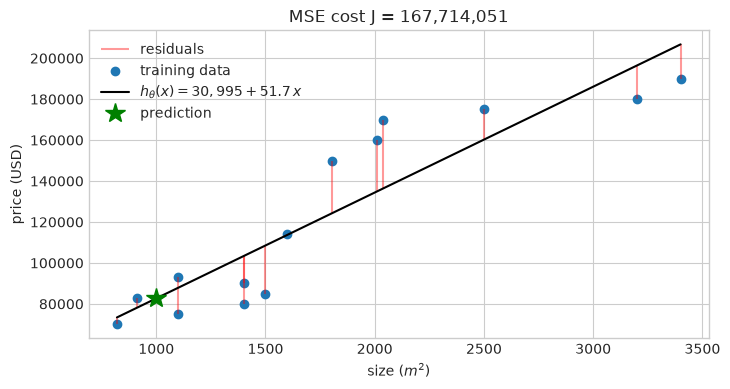

In [3]:
x_new = 1000.0
price = add_bias(np.array([x_new])) @ theta
print(f"Estimated price of a {x_new:.0f} m^2 house: {price[0]:,.0f} USD")

xs = np.linspace(x.min(), x.max(), 2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(x, y, X @ theta, color="r", alpha=0.4, label="residuals")
ax.scatter(x, y, label="training data")
ax.plot(xs, add_bias(xs) @ theta, "k", label=rf"$h_\theta(x) = {theta[0]:,.0f} + {theta[1]:.1f}\,x$")
ax.plot(x_new, price, "g*", ms=15, label="prediction")
ax.set(xlabel="size ($m^2$)", ylabel="price (USD)", title=f"MSE cost J = {mse_cost(theta, X, y):,.0f}")
ax.legend()
plt.show()

## When is $X^TX$ not invertible?

- **Redundant features**: two columns are linearly dependent (e.g. size in $m^2$ and in $ft^2$).
- **Too many features**: $m \le n$.

Fixes: drop redundant features, use the pseudo-inverse $\theta = X^+y$ (what `lstsq` does), or **regularize** with Tikhonov/ridge $\theta = (X^TX + \lambda I)^{-1}X^Ty$ (see [08 Review](08_review.ipynb)).

## Normal equations vs. gradient descent

| Gradient descent | Normal equations |
|:---:|:---:|
| Need to choose $\alpha$ | No $\alpha$ |
| Many iterations | No iterations |
| $O(kn^2)$ | $O(n^3)$ to factor $X^TX$ |
| Works well for large $n$ | Slow when $n \gtrsim 10^4$ |
| Generalizes to nonlinear models | Linear least squares only |

No feature scaling is needed for the normal equations (it does matter for gradient descent).